### Artificial Intelligence 601.464 Project #8: Game Agents

#### Before You Begin...
00. We're using a Jupyter Notebook environment (tutorial available here: https://jupyter-notebook-beginner-guide.readthedocs.io/en/latest/what_is_jupyter.html),
01. Read the entire notebook before beginning your work, and
02.  Check the submission deadline on Gradescope.


#### General Directions for this Assignment
01. Functions should do only one thing,
02. Keep functions to 20 lines or less (empty lines are fine, there's leeway, but don't blatantly ignore this),
03. Add docstring to all functions,


#### Before You Submit...
00. Re-read the general instructions provided above, and
01. Hit "Kernel"->"Restart & Run All". The first cell that is run should show [1], the second should show [2], and so on...
02. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
03.  Do not submit any other files.

### The Problem

For this assignment we will solve difficult game states using any AI technique we learned in this course!
Choose some possible games we can simulate and solve:

We are dividing these games by their intractibility P/NP (P can be solved in polynomial time, NP cannot be solved in polynomial time). With the tools that we've learned in this class we are able to find heuristics that can help solve some of these hard problems in polynomial time!

<span style="color:red">Choose *ONE* game (either P or NP)</span>.


#### P Games (*Only* these options):
These are simple games that have polytime solutions, *make your own game simulation*, and use one of the techniques taught in class.
- Wordle
- Connections
- Crossword Minis
- Strands
- Ultimate Tic-Tac-Toe

#### NP Games (*Any* game, including these!) 
*+5 Extra Credit*

Since these are complex games to simulate we are allowing you to import libraries that help you simulate a game. We have provided some libraries that may help, but you can also use your own! Like P games, use one of the techniques taught in class to solve these games!
- [Sudoku](https://github.com/jeffsieu/py-sudoku/tree/master)
- [Flow](https://github.com/amoralesc/flow/tree/main) (Hard)
- [Solitaire](https://github.com/jamesboehmer/pytience/tree/master)
- [Blackjack](https://github.com/EvanA4/blackjack-api)
- [Poker](https://github.com/uoftcprg/pokerkit) (Hard)
- [Minesweeper](https://github.com/duguyue100/minesweeper/tree/master)
- [Dominoes](https://dominoes.readthedocs.io/en/latest/)
- [Super Mario Bros.](https://github.com/Kautenja/gym-super-mario-bros) 
- Any NP game of your choosing! (Must be NP, provide a link to a website showing this game is NP, NP-Hard, NP-Complete)


These games can all be done using various different tools: some are better suited than others, but it's fun to try different combinations to see what works best.

#### Some Techniques We have learned in this class:
- Classical Search (DFS, BFS, A*, Beam Search)
- Minimax / Minimax+aB
- Multiagent Systems
- Game Theory / Nash Equilibria
- Constraint Satisfaction (MRV, LCV, Backtracking, Backjumping)
- Genetic Algorithms
- Decision Trees and Random Forests
- Reinforcement Learning
- Unsupervised Learning / Clustering Algorithms
- Neural Networks
- Convolutional Neural Networks
- Natural Language Processing and LLMs
- Any other concept we reviewed in class!

## Imports
What game are you simulating?
What tech stack are you using? 
- HuggingFace, pytorch, sk-learn, gymnasium, pygame, or simple built-in libraries. 

Import them here!

I'll be simulating Blackjack using Gymnasium.

In [196]:
# I'm keeping this commented and installing it elsewhere because my ipykernel behaves oddly when I don't, and this makes it easier for me
#!pip install gymnasium


In [197]:
# Imports go here.
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
import random
from collections import defaultdict

%matplotlib inline

## Data
What kind of data are we working with? 
- Historical movesets from games? 
- The past 1000 published games? 
- The map for a world?
- Oxford Dictionary collection of words? 

Import your data here if you have any!

In [198]:
# No data for Blackjack!

## Implementation
Design your model that will solve your game. Choose any of the techniques listed!

In [199]:
# Sets up environment
env = gym.make("Blackjack-v1", sab=True)

In [200]:
def draw_card():
    """Returns a random card value."""
    return min(random.randint(1, 13), 10)

In [201]:
def simulate_dealer(dealer_sum):
    """Simulates dealer play (hits until >= 17)."""
    while dealer_sum < 17:
        dealer_sum += draw_card()
    return dealer_sum

In [202]:
def evaluate_stick(player_sum, dealer_card, simulations=100):
    """Monte Carlo estimate of sticking value."""
    wins = 0

    for _ in range(simulations):
        dealer_sum = dealer_card + draw_card()
        dealer_sum = simulate_dealer(dealer_sum)

        if dealer_sum > 21 or player_sum > dealer_sum:
            wins += 1
        elif player_sum < dealer_sum:
            wins -= 1

    return wins / simulations

In [203]:
def evaluate_hit(player_sum, dealer_card, simulations=100):
    """Monte Carlo estimate of hitting value."""
    total = 0

    for _ in range(simulations):
        new_sum = player_sum + draw_card()

        if new_sum > 21:
            total -= 1
        else:
            total += evaluate_stick(new_sum, dealer_card, simulations=10)

    return total / simulations

In [204]:
def policy(state):
    """Chooses best action using expected value."""
    player_sum, dealer_card, usable_ace = state

    hit_value = evaluate_hit(player_sum, dealer_card)
    stick_value = evaluate_stick(player_sum, dealer_card)

    return 1 if hit_value > stick_value else 0

In [205]:
def random_policy(state):
    """Chooses a random action (used in benchmarking my policy)."""
    return env.action_space.sample()

In [206]:
def run_policy(policy_fn, episodes=10000):
    """Runs a policy for a number of episodes and returns rewards."""
    rewards = []
    first_ep = 0
    reward_sum_inc = 0

    # Iterates through every game
    for episode in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        # Hits until done
        while not done:
            action = policy_fn(state)
            state, reward, done, _, _ = env.step(action)
            total_reward += reward

        # Processes results
        rewards.append(total_reward)
        reward_sum_inc += total_reward

        if (episode + 1) % 500 == 0:
            print(f"{first_ep}-{episode}: Reward={reward_sum_inc}")
            first_ep = episode + 1
            reward_sum_inc = 0



    return rewards

In [207]:
# Runs both policies
print("---RANDOM POLICY---")
model_rewards = run_policy(policy)

print()

print("---EXPECTED VALUE POLICY---")
random_rewards = run_policy(random_policy)

---RANDOM POLICY---
0-499: Reward=-13.0
500-999: Reward=-41.0
1000-1499: Reward=-47.0
1500-1999: Reward=-19.0
2000-2499: Reward=-18.0
2500-2999: Reward=-34.0
3000-3499: Reward=-25.0
3500-3999: Reward=-52.0
4000-4499: Reward=-12.0
4500-4999: Reward=-21.0
5000-5499: Reward=-39.0
5500-5999: Reward=-44.0
6000-6499: Reward=-23.0
6500-6999: Reward=-32.0
7000-7499: Reward=-62.0
7500-7999: Reward=-26.0
8000-8499: Reward=-52.0
8500-8999: Reward=-7.0
9000-9499: Reward=-39.0
9500-9999: Reward=-58.0

---EXPECTED VALUE POLICY---
0-499: Reward=-187.0
500-999: Reward=-185.0
1000-1499: Reward=-196.0
1500-1999: Reward=-186.0
2000-2499: Reward=-194.0
2500-2999: Reward=-236.0
3000-3499: Reward=-223.0
3500-3999: Reward=-193.0
4000-4499: Reward=-219.0
4500-4999: Reward=-221.0
5000-5499: Reward=-227.0
5500-5999: Reward=-200.0
6000-6499: Reward=-176.0
6500-6999: Reward=-209.0
7000-7499: Reward=-177.0
7500-7999: Reward=-171.0
8000-8499: Reward=-150.0
8500-8999: Reward=-194.0
9000-9499: Reward=-216.0
9500-9999

In [208]:
# Computes win rates
model_win_rate = np.mean(np.array(model_rewards) > 0)
random_win_rate = np.mean(np.array(random_rewards) > 0)

In [209]:
# Prints results
print("Model Win Rate:", model_win_rate)
print("Random Win Rate:", random_win_rate)

Model Win Rate: 0.4248
Random Win Rate: 0.2801


In [210]:
def cumulative_win_rate(rewards):
    """Computes cumulative win rate."""
    wins = np.array(rewards) > 0
    return np.cumsum(wins) / np.arange(1, len(wins) + 1)

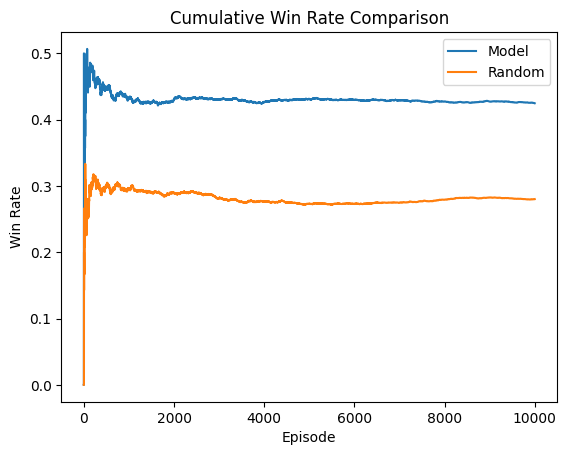

In [211]:
# Plots cumulative win rates
plt.plot(cumulative_win_rate(model_rewards), label="Model")
plt.plot(cumulative_win_rate(random_rewards), label="Random")
plt.title("Cumulative Win Rate Comparison")
plt.xlabel("Episode")
plt.ylabel("Win Rate")
plt.legend()
plt.show()

## Evaluation
**Run your game and model 100 times** (or by how much your data size permits), how many times does your model succeed? 

What is your model's success rate?

If you trained your model, show your loss and accuracy plots here:

In [212]:
test_rewards = []

# Runs 100 simulations
for _ in range(100):
    state, _ = env.reset()
    done = False
    total_reward = 0

    # Uses my EV policy
    while not done:
        action = policy(state)
        state, reward, done, _, _ = env.step(action)
        total_reward += reward

    test_rewards.append(total_reward)

print("Test Win Rate:", np.mean(np.array(test_rewards) > 0))

Test Win Rate: 0.4


## Discussion
Did your model perform as expected? 

What issues did you encounter along the way?

Was the game you chose too complex to model under this timeframe?

Talk about what you learned! 

My model pretty much performed as expected. The win rate was only 43% on the test

## Before You Submit...

00. Re-read the general instructions provided above, and
01. Hit "Kernel"->"Restart & Run All". The first cell that is run should show [1], the second should show [2], and so on...
02. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
03.  Do not submit any other files.